# El efecto del tiempo

**Pregunta:** ¿qué cambia cuando las tareas no llegan todas juntas?

En el notebook 01 todas las cargas existían simultáneamente y encontramos
un umbral de penalidad térmica (~0.32) donde la mejor estrategia se
invertía. Acá agregamos tiempo: las tareas llegan y terminan en momentos
distintos, y las GPUs se apagan cuando quedan vacías.

Eso introduce un costo que antes no podía existir: **encender una GPU
cuesta**. Y ese costo cambia varias conclusiones.

**Cómo correrlo:** ejecutar las celdas en orden. La celda 1 escribe
`simulador.py`; el resto lo importa.

In [3]:
%%writefile simulador.py
"""
Modelo del data center - v5

v2: factor_hotspot pasa de constante global a parametro
v3: generar_workloads_ondas (llegadas con picos y valles)
v4: metricas de latencia (espera_p95, espera_max, sin_iniciar,
    pct_atendidas)
v5: n_tareas parametrizable, para poder saturar el sistema
"""
import random

P_IDLE = 50
P_MAX = 400
EXPONENTE = 3
BOOT_TICKS = 3
BOOT_WATTS = 400
TICKS = 240
N_GPUS = 5
N_TAREAS = 60


class GPU:
    def __init__(self, id, idle_timeout, factor_hotspot):
        self.id = id
        self.idle_timeout = idle_timeout
        self.factor_hotspot = factor_hotspot
        self.estado = "off"
        self.boot_restante = 0
        self.idle_desde = None
        self.tareas = []

    @property
    def carga(self):
        return sum(w.demanda for w in self.tareas)

    def disponible(self):
        return self.estado == "on"

    def potencia(self):
        if self.estado == "off":
            return 0.0
        if self.estado == "booting":
            return BOOT_WATTS
        return P_IDLE + (P_MAX - P_IDLE) * self.carga

    def potencia_cooling(self):
        if self.estado == "off":
            return 0.0
        return self.potencia() * (
            1 + self.factor_hotspot * self.carga ** EXPONENTE)

    def encender(self):
        if self.estado == "off":
            self.estado = "booting"
            self.boot_restante = BOOT_TICKS

    def tick(self, t):
        if self.estado == "booting":
            self.boot_restante -= 1
            if self.boot_restante <= 0:
                self.estado = "on"
                self.idle_desde = t
        elif self.estado == "on":
            if self.tareas:
                self.idle_desde = None
            else:
                if self.idle_desde is None:
                    self.idle_desde = t
                elif t - self.idle_desde >= self.idle_timeout:
                    self.estado = "off"
                    self.idle_desde = None


class Workload:
    def __init__(self, id, llegada, duracion, demanda):
        self.id = id
        self.llegada = llegada
        self.duracion = duracion
        self.demanda = demanda
        self.restante = duracion
        self.inicio = None

    def espera(self):
        return None if self.inicio is None else self.inicio - self.llegada


def elegir_spread(gpus, w):
    c = [g for g in gpus if g.disponible() and g.carga + w.demanda <= 1.0]
    return min(c, key=lambda g: g.carga) if c else None


def elegir_consolidar(gpus, w):
    c = [g for g in gpus if g.disponible() and g.carga + w.demanda <= 1.0]
    return max(c, key=lambda g: g.carga) if c else None


def simular(elegir_gpu, workloads, idle_timeout, factor_hotspot):
    gpus = [GPU(i, idle_timeout, factor_hotspot) for i in range(N_GPUS)]
    gpus[0].estado = "on"
    pendientes = sorted(workloads, key=lambda w: w.llegada)
    cola = []
    energia_it = 0.0
    energia_cool = 0.0
    encendidos = 0

    for t in range(TICKS):
        while pendientes and pendientes[0].llegada == t:
            cola.append(pendientes.pop(0))

        sin_lugar = []
        for w in cola:
            g = elegir_gpu(gpus, w)
            if g:
                g.tareas.append(w)
                w.inicio = t
            else:
                sin_lugar.append(w)
        cola = sin_lugar

        if cola:
            apagadas = [g for g in gpus if g.estado == "off"]
            if apagadas:
                apagadas[0].encender()
                encendidos += 1

        energia_it += sum(g.potencia() for g in gpus) / 60 / 1000
        energia_cool += sum(g.potencia_cooling() - g.potencia()
                            for g in gpus) / 60 / 1000

        for g in gpus:
            for w in list(g.tareas):
                w.restante -= 1
                if w.restante <= 0:
                    g.tareas.remove(w)
            g.tick(t)

    iniciadas = [w for w in workloads if w.inicio is not None]
    esperas = sorted(w.espera() for w in iniciadas)
    sin_iniciar = len(workloads) - len(iniciadas)

    def percentil(datos, p):
        if not datos:
            return 0
        i = min(int(p * len(datos)), len(datos) - 1)
        return datos[i]

    return {
        "total": energia_it + energia_cool,
        "it": energia_it,
        "cool": energia_cool,
        "encendidos": encendidos,
        # --- latencia ---
        # OJO: prom/p95/max solo cuentan las tareas que ARRANCARON.
        # Sin mirar sin_iniciar, un scheduler que mata tareas parece rapido.
        "espera_prom": sum(esperas) / len(esperas) if esperas else 0,
        "espera_p95": percentil(esperas, 0.95),
        "espera_max": esperas[-1] if esperas else 0,
        "sin_iniciar": sin_iniciar,
        "pct_atendidas": len(iniciadas) / len(workloads) * 100,
    }


def generar_workloads(semilla):
    rng = random.Random(semilla)
    return [Workload(
        id=i,
        llegada=rng.randint(0, TICKS - 40),
        duracion=rng.randint(10, 40),
        demanda=round(rng.uniform(0.1, 0.6), 2),
    ) for i in range(N_TAREAS)]


def generar_workloads_ondas(semilla, amplitud=1.0, ciclos=2,
                            n_tareas=N_TAREAS):
    """Como generar_workloads, pero las llegadas se concentran en picos.

    amplitud = 0.0 -> llegadas parejas (control)
    amplitud = 1.0 -> picos y valles marcados
    ciclos         -> cuantas olas entran en la simulacion
    n_tareas       -> subirlo satura el sistema
    """
    import math
    rng = random.Random(semilla)
    ventana = TICKS - 40

    # Peso de cada minuto: una onda que sube y baja.
    pesos = [1 + amplitud * math.sin(2 * math.pi * ciclos * t / ventana)
             for t in range(ventana)]
    pesos = [max(p, 0.01) for p in pesos]      # nunca negativo

    llegadas = rng.choices(range(ventana), weights=pesos, k=n_tareas)

    return [Workload(
        id=i,
        llegada=llegadas[i],
        duracion=rng.randint(10, 40),
        demanda=round(rng.uniform(0.1, 0.6), 2),
    ) for i in range(n_tareas)]

Overwriting simulador.py


## 1. ¿Cuánto conviene esperar antes de apagar una GPU?

Si se apaga muy rápido, hay que encenderla de nuevo enseguida y se paga
el arranque (*thrashing*). Si se espera demasiado, se paga el consumo en
vacío. Debería existir un punto intermedio.

Cada punto es el promedio de 30 escenarios distintos. Una sola corrida
no alcanza: con n=1 la curva salía llena de saltos y el "óptimo" caía
en un valor distinto cada vez.

n = 30 escenarios por punto | factor_hotspot = 0.35

timeout |           SPREAD   arr |       CONSOLIDAR   arr
------------------------------------------------------------
      1 |   4.619 +-0.342  15.8 |   4.794 +-0.325  19.7
      2 |   4.557 +-0.339  12.5 |   4.771 +-0.344  17.4
      3 |   4.508 +-0.351   9.8 |   4.744 +-0.342  15.4
      5 |   4.469 +-0.350   7.6 |   4.717 +-0.347  13.0
      8 |   4.452 +-0.335   5.7 |   4.707 +-0.330  11.2
     10 |   4.459 +-0.332   5.3 |   4.697 +-0.348  10.0
     15 |   4.464 +-0.329   4.4 |   4.693 +-0.345   8.2
     20 |   4.478 +-0.329   4.2 |   4.701 +-0.341   7.4
     30 |   4.496 +-0.327   4.0 |   4.698 +-0.343   5.5
     45 |   4.505 +-0.326   4.0 |   4.715 +-0.333   4.7
     60 |   4.506 +-0.325   4.0 |   4.734 +-0.333   4.4
     90 |   4.507 +-0.325   4.0 |   4.740 +-0.330   4.1

Optimo SPREAD    : 8 min (4.452 +- 0.335 kWh)
Optimo CONSOLIDAR: 15 min (4.693 +- 0.345 kWh)

--- El optimo de SPREAD es real? ---
  vs timeout   1: +0.167

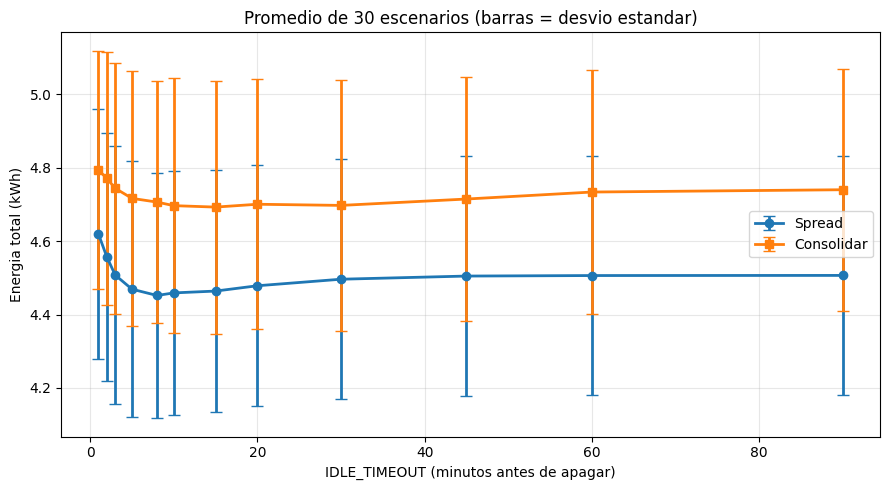

In [5]:
"""
Celda 2: barrido de IDLE_TIMEOUT con 30 semillas.
Pregunta: cuanto conviene esperar antes de apagar una GPU vacia?
"""
import statistics
import matplotlib.pyplot as plt
from simulador import (simular, generar_workloads,
                       elegir_spread, elegir_consolidar)

N_SEMILLAS = 30
FACTOR = 0.35          # el valor que usabamos antes como constante global
timeouts = [1, 2, 3, 5, 8, 10, 15, 20, 30, 45, 60, 90]


def evaluar(elegir_gpu, idle_timeout, factor=FACTOR):
    totales, arranques = [], []
    for s in range(N_SEMILLAS):
        r = simular(elegir_gpu, generar_workloads(s), idle_timeout, factor)
        totales.append(r["total"])
        arranques.append(r["encendidos"])
    return {
        "media": statistics.mean(totales),
        "desvio": statistics.stdev(totales),
        "arranques": statistics.mean(arranques),
    }


spread = [evaluar(elegir_spread, to) for to in timeouts]
consol = [evaluar(elegir_consolidar, to) for to in timeouts]

print(f"n = {N_SEMILLAS} escenarios por punto | factor_hotspot = {FACTOR}\n")
print(f"{'timeout':>7} | {'SPREAD':>16} {'arr':>5} | "
      f"{'CONSOLIDAR':>16} {'arr':>5}")
print("-" * 60)
for to, a, b in zip(timeouts, spread, consol):
    print(f"{to:>7} | {a['media']:>7.3f} +-{a['desvio']:>5.3f} "
          f"{a['arranques']:>5.1f} | "
          f"{b['media']:>7.3f} +-{b['desvio']:>5.3f} {b['arranques']:>5.1f}")

i_a = min(range(len(timeouts)), key=lambda i: spread[i]["media"])
i_b = min(range(len(timeouts)), key=lambda i: consol[i]["media"])

print(f"\nOptimo SPREAD    : {timeouts[i_a]} min "
      f"({spread[i_a]['media']:.3f} +- {spread[i_a]['desvio']:.3f} kWh)")
print(f"Optimo CONSOLIDAR: {timeouts[i_b]} min "
      f"({consol[i_b]['media']:.3f} +- {consol[i_b]['desvio']:.3f} kWh)")

print("\n--- El optimo de SPREAD es real? ---")
mejor = spread[i_a]
margen = 2 * mejor["desvio"] / (N_SEMILLAS ** 0.5)
for i, to in enumerate(timeouts):
    if i == i_a:
        continue
    dif = spread[i]["media"] - mejor["media"]
    print(f"  vs timeout {to:>3}: +{dif:.4f} kWh -> "
          f"{'distinto' if dif > margen else 'indistinguible'}")

plt.figure(figsize=(9, 5))
plt.errorbar(timeouts, [r["media"] for r in spread],
             yerr=[r["desvio"] for r in spread],
             fmt="o-", capsize=4, label="Spread", linewidth=2)
plt.errorbar(timeouts, [r["media"] for r in consol],
             yerr=[r["desvio"] for r in consol],
             fmt="s-", capsize=4, label="Consolidar", linewidth=2)
plt.xlabel("IDLE_TIMEOUT (minutos antes de apagar)")
plt.ylabel("Energia total (kWh)")
plt.title(f"Promedio de {N_SEMILLAS} escenarios (barras = desvio estandar)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Resultado:** la U existe. Óptimo aparente en 8 minutos para spread,
15 para consolidar.

**Pero el test dice que casi nada es distinguible.** Once de doce
vecinos caen dentro del ruido (±0.33 kWh). Lo único claro es que un
timeout de 1 minuto es malo.

Y hay algo que no cierra: spread gana en los 12 timeouts, 12 de 12.
Si fuera azar, debería perder alguno. El problema está en cómo estamos
midiendo, no en los datos.

## 2. El mismo experimento, mejor analizado

Ese ±0.33 no viene de la política de scheduling: viene de que algunos
escenarios tienen más trabajo que otros. Y como usamos **las mismas 30
semillas** en todas las configuraciones (*common random numbers*), esa
dificultad está presente en los dos lados por igual.

Comparando escenario contra escenario en vez de promedio contra
promedio, la dificultad se cancela por resta. Es la misma lógica que
medir a cada paciente antes y después, en lugar de comparar dos grupos
distintos de pacientes.

SPREAD vs CONSOLIDAR (pareado) | factor_hotspot = 0.35
timeout |  dif media   +-error |  gana spread
--------------------------------------------------------------
      1 |     0.1747    0.0141 |      30/30  ***
      2 |     0.2141    0.0171 |      29/30  ***
      3 |     0.2366    0.0134 |      30/30  ***
      5 |     0.2476    0.0134 |      30/30  ***
      8 |     0.2546    0.0103 |      30/30  ***
     10 |     0.2379    0.0137 |      30/30  ***
     15 |     0.2289    0.0118 |      30/30  ***
     20 |     0.2222    0.0101 |      30/30  ***
     30 |     0.2012    0.0112 |      30/30  ***
     45 |     0.2100    0.0103 |      30/30  ***
     60 |     0.2277    0.0108 |      30/30  ***
     90 |     0.2336    0.0086 |      30/30  ***

(*** = la diferencia supera 2 errores estandar)

SPREAD: cada timeout vs el mejor (pareado)
timeout |  dif vs 8min   +-error |  peor que 8
--------------------------------------------------------------
      1 |       0.1673    0.0135 |      30/30

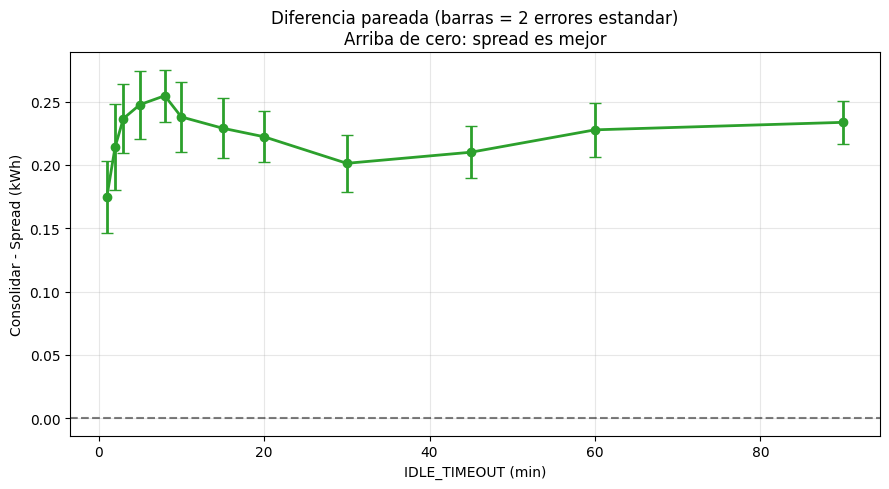

In [6]:
"""
Celda 3: analisis PAREADO.
Los promedios de la celda 2 tenian demasiado ruido. Aca comparamos
escenario contra escenario en vez de promedio contra promedio.
"""
import statistics
import matplotlib.pyplot as plt
from simulador import (simular, generar_workloads,
                       elegir_spread, elegir_consolidar)

N_SEMILLAS = 30
FACTOR = 0.35
timeouts = [1, 2, 3, 5, 8, 10, 15, 20, 30, 45, 60, 90]


def corridas(elegir_gpu, idle_timeout, factor=FACTOR):
    """Energias, una por semilla, EN ORDEN."""
    return [simular(elegir_gpu, generar_workloads(s), idle_timeout,
                    factor)["total"]
            for s in range(N_SEMILLAS)]


def resumen_pareado(a, b):
    """a y b alineadas por semilla. Compara b - a."""
    difs = [x - y for x, y in zip(b, a)]
    return {
        "media": statistics.mean(difs),
        "desvio": statistics.stdev(difs),
        "error": statistics.stdev(difs) / (N_SEMILLAS ** 0.5),
        "gana_a": sum(1 for d in difs if d > 0),
    }


print("=" * 62)
print(f"SPREAD vs CONSOLIDAR (pareado) | factor_hotspot = {FACTOR}")
print("=" * 62)
print(f"{'timeout':>7} | {'dif media':>10} {'+-error':>9} | {'gana spread':>12}")
print("-" * 62)

for to in timeouts:
    r = resumen_pareado(corridas(elegir_spread, to),
                        corridas(elegir_consolidar, to))
    marca = "***" if abs(r["media"]) > 2 * r["error"] else "   "
    print(f"{to:>7} | {r['media']:>10.4f} {r['error']:>9.4f} | "
          f"{r['gana_a']:>7}/{N_SEMILLAS}  {marca}")

print("\n(*** = la diferencia supera 2 errores estandar)")

print("\n" + "=" * 62)
print("SPREAD: cada timeout vs el mejor (pareado)")
print("=" * 62)

base = corridas(elegir_spread, 8)
print(f"{'timeout':>7} | {'dif vs 8min':>12} {'+-error':>9} | {'peor que 8':>11}")
print("-" * 62)

for to in timeouts:
    if to == 8:
        continue
    r = resumen_pareado(base, corridas(elegir_spread, to))
    marca = "***" if r["media"] > 2 * r["error"] else "   "
    print(f"{to:>7} | {r['media']:>12.4f} {r['error']:>9.4f} | "
          f"{r['gana_a']:>7}/{N_SEMILLAS}  {marca}")

medias, errores = [], []
for to in timeouts:
    r = resumen_pareado(corridas(elegir_spread, to),
                        corridas(elegir_consolidar, to))
    medias.append(r["media"])
    errores.append(2 * r["error"])

plt.figure(figsize=(9, 5))
plt.errorbar(timeouts, medias, yerr=errores, fmt="o-",
             capsize=4, linewidth=2, color="tab:green")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.xlabel("IDLE_TIMEOUT (min)")
plt.ylabel("Consolidar - Spread (kWh)")
plt.title("Diferencia pareada (barras = 2 errores estandar)\n"
          "Arriba de cero: spread es mejor")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**El error pasó de 0.061 a 0.010.** Se eliminó cerca del 97% de la
varianza sin generar un solo dato nuevo.

Ahora sí: spread le gana a consolidar en 30 de 30 escenarios, en 11 de
los 12 timeouts. Y la meseta se achicó: solo los timeouts de 10 y 15
minutos siguen indistinguibles del de 8.

**Lección:** el mismo experimento, mejor analizado, da conclusiones más
fuertes. No hacían falta más datos.

## 3. El mapa completo

Hasta acá barrimos un parámetro por vez. Pero hay dos números
inventados que se pelean entre sí: `FACTOR_HOTSPOT` (el castigo por
concentrar calor) y `IDLE_TIMEOUT` (cuánto esperar antes de apagar).

Los barremos juntos. La pregunta es la forma de la frontera: si es
horizontal, domina el factor térmico; si es vertical, domina el
timeout; si es diagonal, los dos interactúan.

Calculando........... listo

Diferencia (Consolidar - Spread) en kWh
Positivo = gana SPREAD | Negativo = gana CONSOLIDAR

factor\timeout        1       2       3       5       8      15      30      60
       0.0       0.036   0.045   0.050   0.033   0.018  -0.027  -0.060  -0.033
       0.1       0.076   0.093   0.103   0.095   0.085   0.046   0.015   0.042
       0.2       0.115   0.142   0.156   0.156   0.153   0.119   0.089   0.116
       0.3       0.155   0.190   0.210   0.217   0.221   0.192   0.164   0.190
       0.4       0.194   0.238   0.263   0.278   0.288   0.265   0.239   0.265
       0.5       0.234   0.287   0.317   0.339   0.356   0.339   0.313   0.339
       0.7       0.313   0.383   0.424   0.462   0.491   0.485   0.462   0.488
       1.0       0.431   0.528   0.584   0.645   0.694   0.704   0.686   0.711


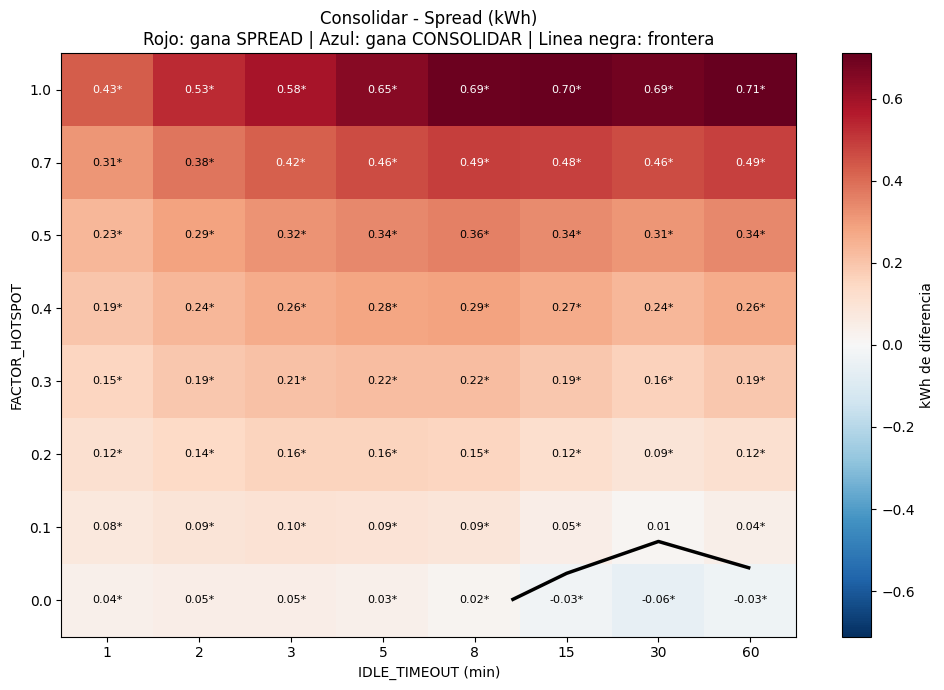


(* = diferencia mayor a 2 errores estandar)


In [7]:
"""
Celda 4: MAPA 2D
Barremos factor_hotspot Y idle_timeout al mismo tiempo.
Color = por cuanto gana. Linea negra = frontera donde empatan.
Todo con comparacion pareada (30 semillas).
"""
import statistics
import numpy as np
import matplotlib.pyplot as plt
from simulador import (simular, generar_workloads,
                       elegir_spread, elegir_consolidar)

N_SEMILLAS = 30
factores = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
timeouts = [1, 2, 3, 5, 8, 15, 30, 60]

def dif_pareada(idle_timeout, factor_hotspot):
    """Consolidar - Spread, promediando diferencias por escenario.
    Positivo = gana spread.

    Ojo: generamos los workloads DE NUEVO en cada simulacion porque
    simular() los consume (les modifica 'restante' e 'inicio').
    Reusar la misma lista daria resultados basura en la segunda corrida.
    """
    difs = []
    for s in range(N_SEMILLAS):
        a = simular(elegir_spread, generar_workloads(s),
                    idle_timeout, factor_hotspot)["total"]
        b = simular(elegir_consolidar, generar_workloads(s),
                    idle_timeout, factor_hotspot)["total"]
        difs.append(b - a)
    return statistics.mean(difs), statistics.stdev(difs) / (N_SEMILLAS ** 0.5)


mapa = np.zeros((len(factores), len(timeouts)))
errores = np.zeros((len(factores), len(timeouts)))

print("Calculando...", end="", flush=True)
for i, f in enumerate(factores):
    for j, to in enumerate(timeouts):
        m, e = dif_pareada(to, f)
        mapa[i, j] = m
        errores[i, j] = e
    print(".", end="", flush=True)
print(" listo\n")

# ---------- TABLA ----------
print("Diferencia (Consolidar - Spread) en kWh")
print("Positivo = gana SPREAD | Negativo = gana CONSOLIDAR\n")
print("factor\\timeout " + "".join(f"{to:>8}" for to in timeouts))
for i, f in enumerate(factores):
    fila = "".join(f"{mapa[i, j]:>8.3f}" for j in range(len(timeouts)))
    print(f"{f:>10.1f}    {fila}")

# ---------- GRAFICO ----------
lim = np.abs(mapa).max()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(mapa, cmap="RdBu_r", vmin=-lim, vmax=lim,
               origin="lower", aspect="auto")

# Frontera: donde la diferencia es cero
X, Y = np.meshgrid(range(len(timeouts)), range(len(factores)))
try:
    ax.contour(X, Y, mapa, levels=[0], colors="black", linewidths=2.5)
except Exception:
    pass

# Numeros en cada celda; * si es significativo
for i in range(len(factores)):
    for j in range(len(timeouts)):
        sig = "*" if abs(mapa[i, j]) > 2 * errores[i, j] else ""
        ax.text(j, i, f"{mapa[i, j]:.2f}{sig}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(mapa[i, j]) > lim * 0.55 else "black")

ax.set_xticks(range(len(timeouts)))
ax.set_xticklabels(timeouts)
ax.set_yticks(range(len(factores)))
ax.set_yticklabels(factores)
ax.set_xlabel("IDLE_TIMEOUT (min)")
ax.set_ylabel("FACTOR_HOTSPOT")
ax.set_title("Consolidar - Spread (kWh)\n"
             "Rojo: gana SPREAD | Azul: gana CONSOLIDAR | "
             "Linea negra: frontera")
plt.colorbar(im, ax=ax, label="kWh de diferencia")
plt.tight_layout()
plt.show()

print("\n(* = diferencia mayor a 2 errores estandar)")

**La frontera es horizontal y está pegada al piso.**

⚠️ **Esto invalida el resultado del notebook 01.** Allí encontramos
umbral en 0.32 — "por debajo gana consolidar". En el mapa, consolidar
solo gana en un rincón mínimo: factor exactamente 0.0 y timeout ≥15.

**El umbral se desplomó de 0.32 a prácticamente 0.** El costo de
arranque, que el modelo estático ignoraba, es una tercera fuerza que
castiga a consolidar. Dos contra una.

Además, ese rincón azul es físicamente sospechoso: `factor = 0.0`
significa que concentrar todo el calor no cuesta nada extra en
refrigeración. Eso no existe en una instalación real.

**Nota:** el parámetro crítico ya no es el factor térmico. Ahora es
`BOOT_TICKS` / `BOOT_WATTS`, que nunca barrimos.

## 4. ¿Y si el scheduler decide según el contexto?

Spread y consolidar son reglas fijas: aplican siempre lo mismo sin
mirar la situación. Pero la mejor decisión parecería depender del
estado del sistema.

**Hipótesis:** con poca carga conviene consolidar (matar el idle); con
mucha carga conviene repartir (evitar hotspots).

Los umbrales 0.0 y 1.0 son controles de sanidad: deberían reproducir
exactamente spread y consolidar respectivamente.

timeout = 8 | factor_hotspot = 0.35 | n = 30

SPREAD     : 4.4520 kWh
CONSOLIDAR : 4.7065 kWh

ADAPTATIVO vs SPREAD (pareado)
 umbral |   energia |  vs spread    +-err |  gana adapt
------------------------------------------------------------------
    0.0 |    4.4520 |     0.0000   0.0000 |      30/30     
    0.1 |    4.4519 |    -0.0000   0.0000 |      30/30     
    0.2 |    4.4601 |     0.0082   0.0050 |      20/30     
    0.3 |    4.4869 |     0.0349   0.0072 |       5/30  ***
    0.4 |    4.5319 |     0.0800   0.0089 |       3/30  ***
    0.5 |    4.5985 |     0.1466   0.0114 |       0/30  ***
    0.6 |    4.6583 |     0.2064   0.0134 |       0/30  ***
    0.7 |    4.6838 |     0.2318   0.0090 |       0/30  ***
    0.8 |    4.7034 |     0.2514   0.0087 |       0/30  ***
    0.9 |    4.7069 |     0.2549   0.0104 |       0/30  ***
    1.0 |    4.7065 |     0.2546   0.0103 |       0/30  ***

(vs spread positivo = spread es mejor)
(*** = diferencia mayor a 2 errores estandar)

Mejo

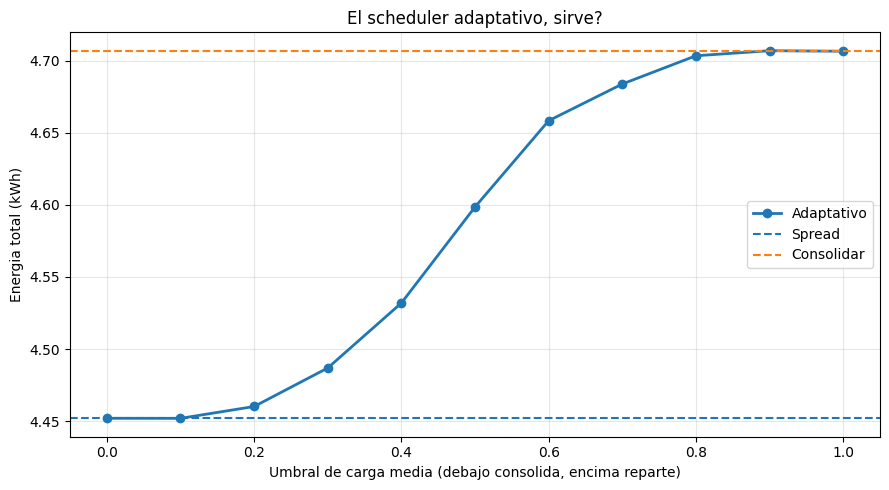

In [8]:
"""
Celda 5: TERCER SCHEDULER (adaptativo)
La idea: no aplicar siempre la misma regla, sino mirar cuan cargado
esta el sistema y elegir.
  - sistema flojo  -> consolidar (matar el idle)
  - sistema cargado -> spread (evitar hotspots)
Comparamos contra spread, que es el campeon actual.
"""
import statistics
import matplotlib.pyplot as plt
from simulador import (simular, generar_workloads,
                       elegir_spread, elegir_consolidar)

N_SEMILLAS = 30
FACTOR = 0.35
TIMEOUT = 8


def hacer_adaptativo(umbral):
    """Fabrica un scheduler con ese umbral adentro.
    Devuelve una FUNCION, no un resultado."""

    def elegir_adaptativo(gpus, w):
        prendidas = [g for g in gpus if g.disponible()]
        if not prendidas:
            return None
        carga_media = sum(g.carga for g in prendidas) / len(prendidas)
        if carga_media < umbral:
            return elegir_consolidar(gpus, w)
        return elegir_spread(gpus, w)

    return elegir_adaptativo


def corridas(elegir_gpu, timeout=TIMEOUT, factor=FACTOR):
    return [simular(elegir_gpu, generar_workloads(s), timeout,
                    factor)["total"]
            for s in range(N_SEMILLAS)]


def pareado(a, b):
    """b - a, por escenario. Positivo = a es mejor."""
    difs = [y - x for x, y in zip(a, b)]
    return {
        "media": statistics.mean(difs),
        "error": statistics.stdev(difs) / (N_SEMILLAS ** 0.5),
        "gana_a": sum(1 for d in difs if d > 0),
    }


# ---------- BASE: los dos de siempre ----------
base_spread = corridas(elegir_spread)
base_consol = corridas(elegir_consolidar)

print(f"timeout = {TIMEOUT} | factor_hotspot = {FACTOR} | "
      f"n = {N_SEMILLAS}\n")
print(f"SPREAD     : {statistics.mean(base_spread):.4f} kWh")
print(f"CONSOLIDAR : {statistics.mean(base_consol):.4f} kWh")

# ---------- BARRIDO DEL UMBRAL ----------
umbrales = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

print("\n" + "=" * 66)
print("ADAPTATIVO vs SPREAD (pareado)")
print("=" * 66)
print(f"{'umbral':>7} | {'energia':>9} | {'vs spread':>10} {'+-err':>8} | "
      f"{'gana adapt':>11}")
print("-" * 66)

resultados = []
for u in umbrales:
    r = corridas(hacer_adaptativo(u))
    resultados.append(r)
    p = pareado(base_spread, r)          # positivo = spread mejor
    marca = "***" if abs(p["media"]) > 2 * p["error"] else "   "
    gana_adapt = N_SEMILLAS - p["gana_a"]
    print(f"{u:>7.1f} | {statistics.mean(r):>9.4f} | "
          f"{p['media']:>10.4f} {p['error']:>8.4f} | "
          f"{gana_adapt:>7}/{N_SEMILLAS}  {marca}")

print("\n(vs spread positivo = spread es mejor)")
print("(*** = diferencia mayor a 2 errores estandar)")

mejor_i = min(range(len(umbrales)),
              key=lambda i: statistics.mean(resultados[i]))
mejor_u = umbrales[mejor_i]
p_mejor = pareado(base_spread, resultados[mejor_i])

print(f"\nMejor umbral: {mejor_u} "
      f"({statistics.mean(resultados[mejor_i]):.4f} kWh)")
if p_mejor["media"] > 2 * p_mejor["error"]:
    print("  -> SPREAD sigue ganando, con diferencia significativa")
elif p_mejor["media"] < -2 * p_mejor["error"]:
    print("  -> EL ADAPTATIVO LE GANA A SPREAD")
else:
    print("  -> empate estadistico con spread")

# ---------- GRAFICO ----------
medias = [statistics.mean(r) for r in resultados]

plt.figure(figsize=(9, 5))
plt.plot(umbrales, medias, "o-", linewidth=2, label="Adaptativo")
plt.axhline(statistics.mean(base_spread), color="tab:blue",
            linestyle="--", label="Spread")
plt.axhline(statistics.mean(base_consol), color="tab:orange",
            linestyle="--", label="Consolidar")
plt.xlabel("Umbral de carga media (debajo consolida, encima reparte)")
plt.ylabel("Energia total (kWh)")
plt.title("El scheduler adaptativo, sirve?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Los controles pasan** (0.0 = spread, 1.0 = consolidar), así que el
código hace lo que dice.

**Y la curva es monótona:** cada grado de consolidación empeora el
resultado. El "mejor umbral" es 0.1, que es donde el adaptativo casi
nunca se activa. La mejor versión del scheduler adaptativo es la que
no adapta.

La hipótesis de fondo era falsa: con estos parámetros consolidar no
conviene nunca, ni con el sistema vacío.

## 5. ¿Falló la idea o falló la métrica?

La celda 5 probó una sola métrica (carga media) en un solo régimen
—justamente uno donde ya sabíamos que spread domina—. Antes de
descartar la idea, hay que probarla mejor.

Tres métricas × tres regímenes:

- `MEDIA` — carga promedio de las GPUs encendidas
- `FRACCION` — qué porcentaje del parque está encendido
- `PICO` — la carga de la GPU más cargada
`PICO` es la mejor fundamentada a priori: el costo de refrigeración
depende de `carga³` **por GPU**, así que el promedio es ciego justo a
lo que genera el costo. Esto conecta con la literatura de *thermal-aware
scheduling*.

In [9]:
"""
Celda 6: el adaptativo, bien probado.
Dos preguntas:
  1) Gana en el rincon donde consolidar era competitivo?
  2) Cambia algo si mira una metrica mejor?

Tres metricas:
  MEDIA    - carga promedio de las GPUs prendidas (la de la celda 5)
  FRACCION - que porcentaje del parque esta prendido
  PICO     - la carga de la GPU MAS cargada (mira el hotspot directo)
"""
import statistics
from simulador import (simular, generar_workloads, N_GPUS,
                       elegir_spread, elegir_consolidar)

N_SEMILLAS = 30
umbrales = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]

# (nombre, factor_hotspot, idle_timeout)
regimenes = [
    ("rincon favorable ", 0.0, 30),
    ("intermedio       ", 0.1, 30),
    ("linea base       ", 0.35, 8),
]


def hacer(metrica, umbral):
    """metrica: funcion que recibe las GPUs prendidas y da un numero."""
    def elegir(gpus, w):
        prendidas = [g for g in gpus if g.disponible()]
        if not prendidas:
            return None
        if metrica(prendidas) < umbral:
            return elegir_consolidar(gpus, w)
        return elegir_spread(gpus, w)
    return elegir


m_media = lambda ps: sum(g.carga for g in ps) / len(ps)
m_fraccion = lambda ps: len(ps) / N_GPUS
m_pico = lambda ps: max(g.carga for g in ps)

metricas = [("MEDIA", m_media), ("FRACCION", m_fraccion), ("PICO", m_pico)]


def corridas(elegir_gpu, timeout, factor):
    return [simular(elegir_gpu, generar_workloads(s), timeout,
                    factor)["total"]
            for s in range(N_SEMILLAS)]


def pareado(base, otro):
    """otro - base. Negativo = otro es MEJOR que base."""
    difs = [b - a for a, b in zip(base, otro)]
    return statistics.mean(difs), statistics.stdev(difs) / (N_SEMILLAS ** 0.5)


for nombre, factor, timeout in regimenes:
    print("=" * 70)
    print(f"{nombre.strip().upper()}  (factor={factor}, timeout={timeout})")
    print("=" * 70)

    base = corridas(elegir_spread, timeout, factor)
    cons = corridas(elegir_consolidar, timeout, factor)
    d_c, e_c = pareado(base, cons)

    print(f"  SPREAD     : {statistics.mean(base):.4f} kWh  (referencia)")
    print(f"  CONSOLIDAR : {statistics.mean(cons):.4f} kWh  "
          f"({d_c:+.4f} +-{e_c:.4f})")
    print()
    print(f"  {'metrica':>9} {'umbral':>7} {'energia':>9} "
          f"{'vs spread':>11} {'+-err':>8}   veredicto")
    print("  " + "-" * 62)

    for m_nombre, m_fn in metricas:
        # mejor umbral de esta metrica en este regimen
        mejor = None
        for u in umbrales:
            r = corridas(hacer(m_fn, u), timeout, factor)
            media = statistics.mean(r)
            if mejor is None or media < mejor[1]:
                mejor = (u, media, r)

        u, media, r = mejor
        d, e = pareado(base, r)
        if d < -2 * e:
            v = "GANA a spread"
        elif d > 2 * e:
            v = "pierde"
        else:
            v = "empate"
        print(f"  {m_nombre:>9} {u:>7.1f} {media:>9.4f} "
              f"{d:>+11.4f} {e:>8.4f}   {v}")
    print()

print("(vs spread negativo = el adaptativo consume MENOS)")

RINCON FAVORABLE  (factor=0.0, timeout=30)
  SPREAD     : 4.0533 kWh  (referencia)
  CONSOLIDAR : 3.9933 kWh  (-0.0600 +-0.0082)

    metrica  umbral   energia   vs spread    +-err   veredicto
  --------------------------------------------------------------
      MEDIA     0.8    3.9969     -0.0565   0.0079   GANA a spread
   FRACCION     0.8    4.0507     -0.0026   0.0025   empate
       PICO     0.8    4.0409     -0.0125   0.0033   GANA a spread

INTERMEDIO  (factor=0.1, timeout=30)
  SPREAD     : 4.1799 kWh  (referencia)
  CONSOLIDAR : 4.1945 kWh  (+0.0146 +-0.0081)

    metrica  umbral   energia   vs spread    +-err   veredicto
  --------------------------------------------------------------
      MEDIA     0.2    4.1777     -0.0022   0.0024   empate
   FRACCION     0.8    4.1786     -0.0013   0.0020   empate
       PICO     0.4    4.1783     -0.0015   0.0015   empate

LINEA BASE  (factor=0.35, timeout=8)
  SPREAD     : 4.4520 kWh  (referencia)
  CONSOLIDAR : 4.7065 kWh  (+0.2546 +

**En los tres regímenes, el mejor adaptativo converge a una de las dos
políticas puras.**

En el rincón favorable, `MEDIA` con umbral 0.8 da 3.9969 — es
esencialmente consolidar (3.9933). En la línea base, `PICO` con umbral
0.2 da exactamente spread. No descubrieron una estrategia híbrida:
se volvieron una de las dos.

**Por qué:** el régimen no cambia durante la simulación. Si la mejor
política es fija durante toda la corrida, un scheduler que cambia de
opinión solo puede empeorar.

Adaptar sirve cuando las condiciones varían. Acá no varían — las
llegadas son uniformes. Eso da la idea del próximo experimento.

## 6. Carga variable

Ningún data center recibe trabajo a ritmo constante. Con picos y valles
de demanda, el sistema atraviesa regímenes distintos dentro de una misma
corrida, y ahí la pregunta "¿conviene adaptar?" recién tiene sentido.

**El control importa:** `amplitud = 0.0` son llegadas parejas. Si el
adaptativo gana con olas y no gana en el control, la diferencia la causó
la variabilidad y nada más. Sin ese control no podríamos atribuir la
causa.

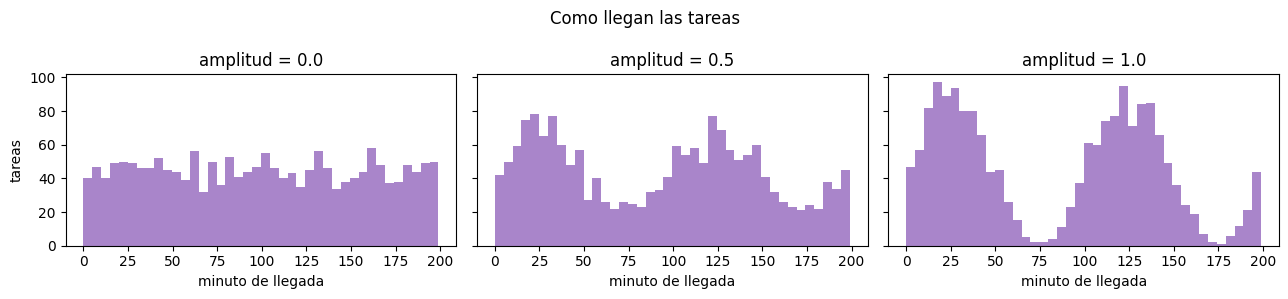

INTERMEDIO  (factor=0.1, timeout=30)
 amplitud  metrica  umbral    spread     adapt        dif    +-err  veredicto
------------------------------------------------------------------------
      0.0   CONSOL       -    4.0246    4.0456    +0.0210   0.0078
             MEDIA     0.3    4.0246    4.0229    -0.0017   0.0046  empate
              PICO     0.4    4.0246    4.0239    -0.0007   0.0012  empate

      0.5   CONSOL       -    4.0443    4.0424    -0.0019   0.0081
             MEDIA     0.3    4.0443    4.0368    -0.0075   0.0060  empate
              PICO     0.5    4.0443    4.0402    -0.0041   0.0030  empate

      1.0   CONSOL       -    4.0537    4.0657    +0.0120   0.0081
             MEDIA     0.2    4.0537    4.0393    -0.0144   0.0054  GANA
              PICO     0.8    4.0537    4.0411    -0.0126   0.0051  GANA

LINEA BASE  (factor=0.35, timeout=8)
 amplitud  metrica  umbral    spread     adapt        dif    +-err  veredicto
-----------------------------------------------

In [10]:
"""
Celda 7: CARGA VARIABLE
Hipotesis: el adaptativo fallaba porque el regimen no cambiaba nunca.
Con picos y valles de demanda, deberia tener algo que hacer.

amplitud 0.0 = llegadas parejas (CONTROL, deberia reproducir la celda 6)
amplitud 1.0 = olas marcadas
"""
import statistics
import matplotlib.pyplot as plt
from simulador import (simular, generar_workloads_ondas, N_GPUS, TICKS,
                       elegir_spread, elegir_consolidar)

N_SEMILLAS = 30
umbrales = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]
amplitudes = [0.0, 0.5, 1.0]

regimenes = [
    ("intermedio", 0.1, 30),
    ("linea base", 0.35, 8),
]

m_media = lambda ps: sum(g.carga for g in ps) / len(ps)
m_pico = lambda ps: max(g.carga for g in ps)
metricas = [("MEDIA", m_media), ("PICO", m_pico)]


def hacer(metrica, umbral):
    def elegir(gpus, w):
        prendidas = [g for g in gpus if g.disponible()]
        if not prendidas:
            return None
        if metrica(prendidas) < umbral:
            return elegir_consolidar(gpus, w)
        return elegir_spread(gpus, w)
    return elegir


def corridas(elegir_gpu, timeout, factor, amplitud):
    return [simular(elegir_gpu, generar_workloads_ondas(s, amplitud),
                    timeout, factor)["total"]
            for s in range(N_SEMILLAS)]


def pareado(base, otro):
    difs = [b - a for a, b in zip(base, otro)]
    return statistics.mean(difs), statistics.stdev(difs) / (N_SEMILLAS ** 0.5)


# ---------- VER LAS OLAS ----------
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, amp in zip(axes, amplitudes):
    todas = []
    for s in range(N_SEMILLAS):
        todas += [w.llegada for w in generar_workloads_ondas(s, amp)]
    ax.hist(todas, bins=40, color="tab:purple", alpha=0.8)
    ax.set_title(f"amplitud = {amp}")
    ax.set_xlabel("minuto de llegada")
axes[0].set_ylabel("tareas")
plt.suptitle("Como llegan las tareas")
plt.tight_layout()
plt.show()


# ---------- EXPERIMENTO ----------
for nombre, factor, timeout in regimenes:
    print("=" * 72)
    print(f"{nombre.upper()}  (factor={factor}, timeout={timeout})")
    print("=" * 72)
    print(f"{'amplitud':>9} {'metrica':>8} {'umbral':>7} "
          f"{'spread':>9} {'adapt':>9} {'dif':>10} {'+-err':>8}  veredicto")
    print("-" * 72)

    for amp in amplitudes:
        base = corridas(elegir_spread, timeout, factor, amp)
        cons = corridas(elegir_consolidar, timeout, factor, amp)
        d_c, e_c = pareado(base, cons)
        print(f"{amp:>9.1f} {'CONSOL':>8} {'-':>7} "
              f"{statistics.mean(base):>9.4f} {statistics.mean(cons):>9.4f} "
              f"{d_c:>+10.4f} {e_c:>8.4f}")

        for m_nombre, m_fn in metricas:
            mejor = None
            for u in umbrales:
                r = corridas(hacer(m_fn, u), timeout, factor, amp)
                if mejor is None or statistics.mean(r) < mejor[1]:
                    mejor = (u, statistics.mean(r), r)
            u, media, r = mejor
            d, e = pareado(base, r)
            if d < -2 * e:
                v = "GANA"
            elif d > 2 * e:
                v = "pierde"
            else:
                v = "empate"
            print(f"{'':>9} {m_nombre:>8} {u:>7.1f} "
                  f"{statistics.mean(base):>9.4f} {media:>9.4f} "
                  f"{d:>+10.4f} {e:>8.4f}  {v}")
        print()

print("(dif negativa = la alternativa consume MENOS que spread)")

**La hipótesis se sostuvo.** En el régimen intermedio la ventaja crece
de forma monótona con la amplitud (−0.0017 → −0.0075 → −0.0144), y el
control de amplitud 0.0 no gana.

⚠️ **Pero cuidado con celebrar:** la ganancia es del 0.35%, y se eligió
el mejor umbral entre seis, en el mejor régimen de dos, con la mejor
métrica de dos. Son 24 combinaciones; encontrar dos que crucen el umbral
de significancia por poco margen es lo esperable por azar.

Hace falta confirmarlo con más semillas y umbrales elegidos de antemano.

**Observación no prevista:** en la línea base, las olas *mejoran* a
consolidar (+0.2251 → +0.1243). Los valles le dan oportunidades de
apagar sin pagar reencendidos. Menos thrashing.

## 7. Confirmación

Test distinto al anterior, diseñado antes de correrlo:

- **100 semillas nuevas** (301–400), nunca usadas en la exploración
- **umbrales congelados** (0.2 y 0.8), sin barrer
- **un solo régimen**, el que dio positivo
- **control incluido**: amplitud 0.0 no debería ganar
**Predicción registrada:** si el efecto es real, MEDIA y PICO ganan con
amplitud 1.0 y nadie gana con amplitud 0.0.

In [11]:
"""
Celda 8: CONFIRMACION
La celda 7 encontro que el adaptativo le gana a spread bajo carga
variable. Pero el umbral se eligio DESPUES de mirar los datos, sobre
30 semillas y 24 combinaciones. Puede ser azar.

Este test es distinto:
  - 100 semillas nuevas (301 a 400), nunca usadas antes
  - umbrales FIJADOS de antemano (los que salieron en la celda 7)
  - un solo regimen, el que dio positivo
  - control incluido: amplitud 0.0 NO deberia ganar

Si el efecto sobrevive esto, es real.
"""
import statistics
from simulador import (simular, generar_workloads_ondas,
                       elegir_spread, elegir_consolidar)

N_SEMILLAS = 100
PRIMERA_SEMILLA = 301        # semillas frescas, no las del entrenamiento

FACTOR = 0.1                 # regimen intermedio
TIMEOUT = 30

# Prefijados desde la celda 7. NO se tocan.
UMBRAL_MEDIA = 0.2
UMBRAL_PICO = 0.8

m_media = lambda ps: sum(g.carga for g in ps) / len(ps)
m_pico = lambda ps: max(g.carga for g in ps)


def hacer(metrica, umbral):
    def elegir(gpus, w):
        prendidas = [g for g in gpus if g.disponible()]
        if not prendidas:
            return None
        if metrica(prendidas) < umbral:
            return elegir_consolidar(gpus, w)
        return elegir_spread(gpus, w)
    return elegir


def corridas(elegir_gpu, amplitud):
    return [simular(elegir_gpu, generar_workloads_ondas(s, amplitud),
                    TIMEOUT, FACTOR)["total"]
            for s in range(PRIMERA_SEMILLA, PRIMERA_SEMILLA + N_SEMILLAS)]


def pareado(base, otro):
    difs = [b - a for a, b in zip(base, otro)]
    media = statistics.mean(difs)
    error = statistics.stdev(difs) / (N_SEMILLAS ** 0.5)
    gana = sum(1 for d in difs if d < 0)
    return media, error, gana


print(f"factor={FACTOR}  timeout={TIMEOUT}  n={N_SEMILLAS} "
      f"(semillas {PRIMERA_SEMILLA}-{PRIMERA_SEMILLA + N_SEMILLAS - 1})")
print(f"umbrales prefijados: MEDIA={UMBRAL_MEDIA}  PICO={UMBRAL_PICO}\n")

candidatos = [
    ("MEDIA", hacer(m_media, UMBRAL_MEDIA)),
    ("PICO", hacer(m_pico, UMBRAL_PICO)),
    ("CONSOLIDAR", elegir_consolidar),
]

for amplitud in [1.0, 0.0]:
    etiqueta = "CARGA VARIABLE" if amplitud else "CONTROL (carga pareja)"
    print("=" * 68)
    print(f"{etiqueta}   amplitud = {amplitud}")
    print("=" * 68)

    base = corridas(elegir_spread, amplitud)
    print(f"  SPREAD (referencia): {statistics.mean(base):.4f} kWh\n")
    print(f"  {'estrategia':>11} {'energia':>9} {'dif':>10} {'+-err':>8} "
          f"{'gana':>8}  veredicto")
    print("  " + "-" * 62)

    for nombre, sched in candidatos:
        r = corridas(sched, amplitud)
        d, e, g = pareado(base, r)
        if d < -2 * e:
            v = "GANA a spread"
        elif d > 2 * e:
            v = "pierde"
        else:
            v = "empate"
        print(f"  {nombre:>11} {statistics.mean(r):>9.4f} {d:>+10.4f} "
              f"{e:>8.4f} {g:>5}/{N_SEMILLAS}  {v}")
    print()

print("(dif negativa = consume MENOS que spread)")
print("\nQue esperar si el efecto es real:")
print("  amplitud 1.0 -> MEDIA y PICO ganan")
print("  amplitud 0.0 -> nadie gana (si aca gana algo, el efecto")
print("                  no venia de la variabilidad)")

factor=0.1  timeout=30  n=100 (semillas 301-400)
umbrales prefijados: MEDIA=0.2  PICO=0.8

CARGA VARIABLE   amplitud = 1.0
  SPREAD (referencia): 4.1971 kWh

   estrategia   energia        dif    +-err     gana  veredicto
  --------------------------------------------------------------
        MEDIA    4.1897    -0.0074   0.0025    56/100  GANA a spread
         PICO    4.1937    -0.0034   0.0028    56/100  empate
   CONSOLIDAR    4.2046    +0.0075   0.0033    38/100  pierde

CONTROL (carga pareja)   amplitud = 0.0
  SPREAD (referencia): 4.1694 kWh

   estrategia   energia        dif    +-err     gana  veredicto
  --------------------------------------------------------------
        MEDIA    4.1702    +0.0008   0.0014    27/100  empate
         PICO    4.1830    +0.0135   0.0023    22/100  pierde
   CONSOLIDAR    4.1982    +0.0287   0.0039    23/100  pierde

(dif negativa = consume MENOS que spread)

Que esperar si el efecto es real:
  amplitud 1.0 -> MEDIA y PICO ganan
  amplitud 0.0

**Sobrevivió la mitad.**

`MEDIA` gana con carga variable (−0.0074 ± 0.0025) y empata en el
control. Patrón exactamente predicho, con datos nuevos.

`PICO` pasó de "GANA" a empate: **era un falso positivo** de las 24
comparaciones anteriores. Era además la métrica mejor fundamentada
teóricamente — el argumento era bueno y estaba equivocado.

**Pero mirá la columna `gana`: 56/100.** Apenas mejor que una moneda.
La diferencia media es significativa, el efecto es del **0.18%** y en
44 escenarios el adaptativo pierde.

> **Significativo no es lo mismo que importante.** Con suficientes datos
> se pueden detectar diferencias que no le importan a nadie.

**Resultado negativo:** la adaptación dinámica no es una vía prometedora
de ahorro energético en este modelo.

## 8. El objetivo que faltaba: latencia

Todo lo anterior mide **solo energía**. Un scheduler que ahorra 30%
dejando a la gente esperando media hora sería declarado ganador por
estos experimentos.

Primero hubo que arreglar la métrica: las tareas que nunca arrancaban
quedaban fuera del promedio de espera, así que un scheduler que mata
tareas *mejoraba* su latencia aparente (*survivorship bias*). Ahora se
reporta `sin_iniciar` junto a las esperas.

Con dos objetivos que se contradicen, "el mejor" deja de existir. Lo que
existe es la **frontera de Pareto**: las configuraciones que nadie supera
en ambos ejes a la vez.


factor=0.35  amplitud=1.0  n=30

      sched  timeout   energia   espera     p95  sin arrancar
--------------------------------------------------------------
     spread        1    4.5013     2.10    11.1           0.0
     spread        3    4.4367     2.02    11.3           0.0
     spread        5    4.4005     1.96    11.4           0.0
     spread        8    4.4029     1.91    11.4           0.0
     spread       15    4.4130     1.87    11.8           0.0
     spread       30    4.4723     1.75    10.9           0.0
     spread       60    4.5108     1.77    11.4           0.0
     spread      120    4.5216     1.77    11.4           0.0
 consolidar        1    4.6067     2.13    10.5           0.0
 consolidar        3    4.5584     1.95    10.5           0.0
 consolidar        5    4.5256     1.83    10.4           0.0
 consolidar        8    4.5272     1.73     9.9           0.0
 consolidar       15    4.5328     1.62     9.4           0.0
 consolidar       30    4.5774     1

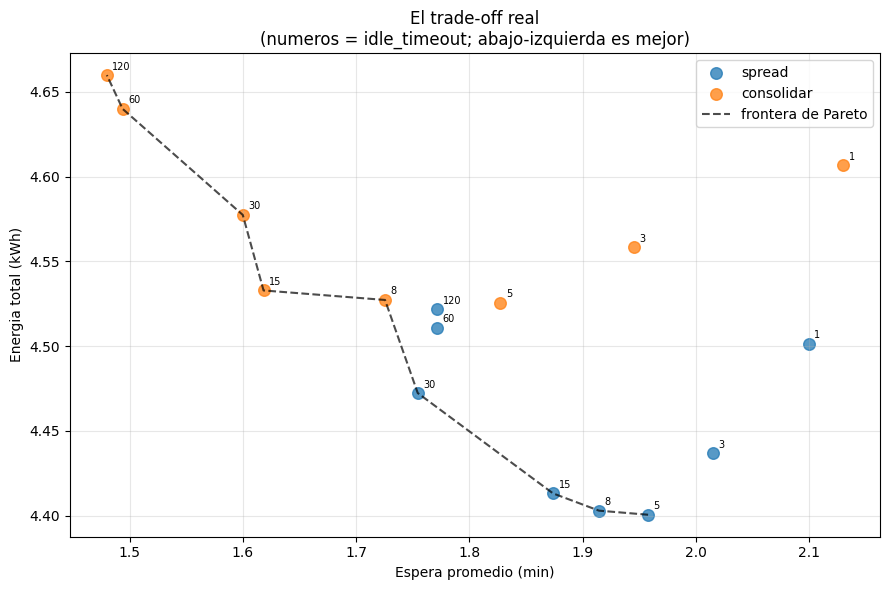

In [12]:
"""
Celda 9: ENERGIA vs LATENCIA
Hasta ahora solo miramos energia. Un scheduler que ahorra energia
haciendo esperar a la gente seria inservible, y no lo detectariamos.

Aca medimos las dos cosas y buscamos la FRONTERA DE PARETO:
las configuraciones que no son superadas en ambos ejes a la vez.
"""
import statistics
import matplotlib.pyplot as plt
from simulador import (simular, generar_workloads_ondas,
                       elegir_spread, elegir_consolidar)

N_SEMILLAS = 30
FACTOR = 0.35
AMPLITUD = 1.0
timeouts = [1, 3, 5, 8, 15, 30, 60, 120]

schedulers = [("spread", elegir_spread), ("consolidar", elegir_consolidar)]


def evaluar(elegir_gpu, timeout):
    e, esp, p95, sin_i = [], [], [], []
    for s in range(N_SEMILLAS):
        r = simular(elegir_gpu, generar_workloads_ondas(s, AMPLITUD),
                    timeout, FACTOR)
        e.append(r["total"])
        esp.append(r["espera_prom"])
        p95.append(r["espera_p95"])
        sin_i.append(r["sin_iniciar"])
    return {
        "energia": statistics.mean(e),
        "espera": statistics.mean(esp),
        "p95": statistics.mean(p95),
        "sin_iniciar": statistics.mean(sin_i),
    }


puntos = []
print(f"factor={FACTOR}  amplitud={AMPLITUD}  n={N_SEMILLAS}\n")
print(f"{'sched':>11} {'timeout':>8} {'energia':>9} {'espera':>8} "
      f"{'p95':>7} {'sin arrancar':>13}")
print("-" * 62)

for nombre, sched in schedulers:
    for to in timeouts:
        r = evaluar(sched, to)
        r["nombre"] = nombre
        r["timeout"] = to
        puntos.append(r)
        print(f"{nombre:>11} {to:>8} {r['energia']:>9.4f} "
              f"{r['espera']:>8.2f} {r['p95']:>7.1f} "
              f"{r['sin_iniciar']:>13.1f}")


# ---------- FRONTERA DE PARETO ----------
def dominado(p, otros):
    """p esta dominado si otro es mejor o igual en ambos ejes,
    y estrictamente mejor en al menos uno."""
    for q in otros:
        if q is p:
            continue
        if (q["energia"] <= p["energia"] and q["espera"] <= p["espera"]
                and (q["energia"] < p["energia"]
                     or q["espera"] < p["espera"])):
            return True
    return False


frontera = [p for p in puntos if not dominado(p, puntos)]
frontera.sort(key=lambda p: p["energia"])

print("\n" + "=" * 62)
print("FRONTERA DE PARETO (nadie les gana en los dos ejes a la vez)")
print("=" * 62)
for p in frontera:
    print(f"  {p['nombre']:>11} timeout={p['timeout']:<4} "
          f"energia={p['energia']:.4f}  espera={p['espera']:.2f} min")

dominados = len(puntos) - len(frontera)
print(f"\n{dominados} de {len(puntos)} configuraciones estan DOMINADAS:")
print("hay otra que consume menos Y hace esperar menos. No hay razon")
print("para elegirlas nunca.")


# ---------- GRAFICO ----------
plt.figure(figsize=(9, 6))
for nombre, color in [("spread", "tab:blue"), ("consolidar", "tab:orange")]:
    sub = [p for p in puntos if p["nombre"] == nombre]
    plt.scatter([p["espera"] for p in sub], [p["energia"] for p in sub],
                s=70, color=color, label=nombre, alpha=0.75)
    for p in sub:
        plt.annotate(str(p["timeout"]),
                     (p["espera"], p["energia"]),
                     fontsize=7, xytext=(4, 4),
                     textcoords="offset points")

plt.plot([p["espera"] for p in frontera], [p["energia"] for p in frontera],
         "k--", linewidth=1.5, alpha=0.7, label="frontera de Pareto")

plt.xlabel("Espera promedio (min)")
plt.ylabel("Energia total (kWh)")
plt.title("El trade-off real\n"
          "(numeros = idle_timeout; abajo-izquierda es mejor)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Consolidar no era peor. Era el otro extremo de un trade-off.**

Cinco de las nueve configuraciones de la frontera son consolidar —todas
las de baja latencia—. Su p95 es sistemáticamente mejor (9–10 min contra
11–12 de spread), en todas las filas.

⚠️ **Esto acota el hallazgo principal del notebook.** Spread no "ganaba":
ganaba en el único eje que estábamos midiendo.

**Mecanismo probable:** consolidar deja GPUs completamente libres, así
que un pico de trabajo encuentra lugar de inmediato. Spread deja todas a
media máquina, y una tarea que necesita 0.6 no entra en ninguna aunque
haya capacidad total de sobra. Es **fragmentación**.

### Estado de las conclusiones

| # | Hallazgo | Estado |
|---|---|---|
| 1 | Umbral térmico ~0.32 (notebook 01) | ⚠️ invalidado por la celda 4 |
| 2 | Con boot cost, consolidar deja de ganar **en energía** | ⚠️ acotado por la celda 9 |
| 3 | El timeout óptimo es una zona (5–15 min), no un valor | ✅ se sostiene |
| 4 | El scheduler adaptativo mejora 0.18% — irrelevante | ❌ resultado negativo |
| 5 | Energía y latencia son un trade-off de Pareto | ✅ se sostiene |

## 9. ¿Y si el sistema no da abasto?

Todo lo anterior se midió en un régimen holgado: cero tareas sin arrancar
en todas las corridas. Las diferencias entre estrategias eran de treinta
segundos de espera.

Subimos la carga de 60 a 300 tareas en la misma ventana de tiempo y
vemos dónde se rompe cada política.

**Trampa a evitar:** cuando hay tareas sin arrancar, comparar energía
total pierde sentido — un scheduler puede "ahorrar" simplemente
atendiendo menos trabajo. Por eso medimos también **Wh por tarea
atendida**.

Se suma el scheduler adaptativo (métrica MEDIA, umbral 0.2), que fue el
único que sobrevivió la confirmación de la celda 8.

60 TAREAS
       sched   energia   Wh/tarea   espera     p95  atendidas
------------------------------------------------------------------------
      spread     4.434      73.89      1.8    11.3     100.0%
  consolidar     4.556      75.93      1.7    10.1     100.0%
  adaptativo     4.435      73.91      1.8    10.9     100.0%

100 TAREAS
       sched   energia   Wh/tarea   espera     p95  atendidas
------------------------------------------------------------------------
      spread     7.422      74.22     11.7    39.6     100.0%
  consolidar     7.484      74.84     11.2    39.0     100.0%
  adaptativo     7.423      74.23     11.6    39.4     100.0%

150 TAREAS
       sched   energia   Wh/tarea   espera     p95  atendidas
------------------------------------------------------------------------
      spread     9.581      70.11     37.5    95.8      91.1%
  consolidar     9.639      70.21     37.1    95.5      91.5%
  adaptativo     9.581      70.11     37.5    95.8      91.1%

20

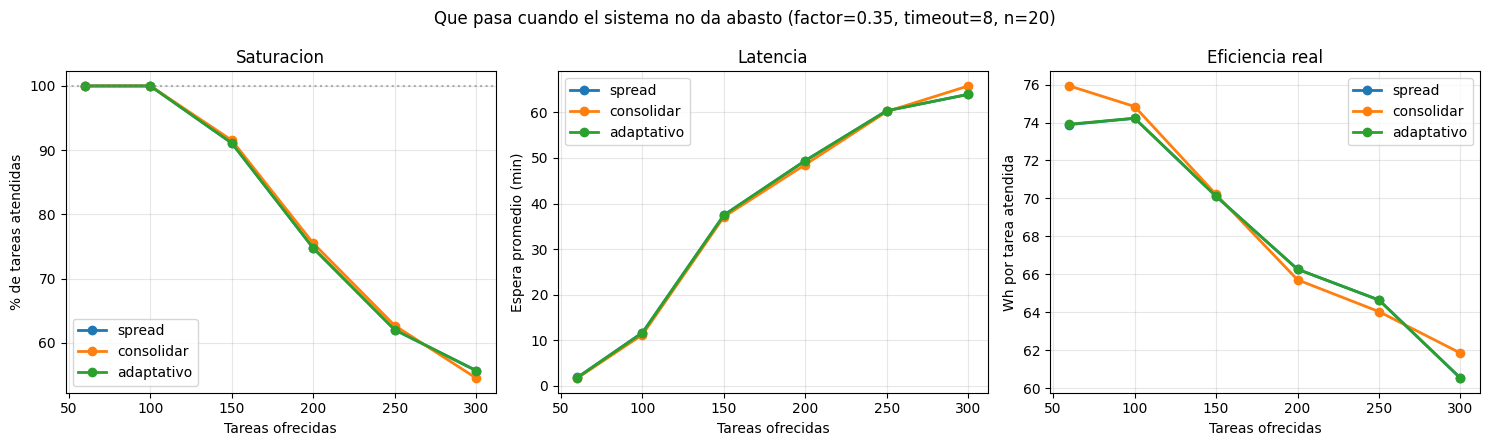

In [4]:
"""
Celda 10: SATURACION
Hasta ahora el sistema nunca se quedaba corto: cero tareas sin arrancar
en todas las corridas. Todas las conclusiones vienen de un regimen holgado.

Subimos la carga de 60 a 300 tareas en la misma ventana de tiempo y
vemos donde se rompe.

OJO con una trampa: cuando hay tareas sin arrancar, comparar energia
total deja de tener sentido. Un scheduler puede "ahorrar" simplemente
atendiendo menos. Por eso medimos tambien kWh POR TAREA ATENDIDA.
"""
import statistics
import matplotlib.pyplot as plt
from simulador import (simular, generar_workloads_ondas,
                       elegir_spread, elegir_consolidar)

N_SEMILLAS = 20
FACTOR = 0.35
TIMEOUT = 8
AMPLITUD = 1.0
cargas = [60, 100, 150, 200, 250, 300]

# El adaptativo que sobrevivio la confirmacion: metrica MEDIA, umbral 0.2
UMBRAL = 0.2


def elegir_adaptativo(gpus, w):
    prendidas = [g for g in gpus if g.disponible()]
    if not prendidas:
        return None
    carga_media = sum(g.carga for g in prendidas) / len(prendidas)
    if carga_media < UMBRAL:
        return elegir_consolidar(gpus, w)
    return elegir_spread(gpus, w)


schedulers = [
    ("spread", elegir_spread),
    ("consolidar", elegir_consolidar),
    ("adaptativo", elegir_adaptativo),
]


def evaluar(sched, n_tareas):
    e, esp, p95, pct = [], [], [], []
    for s in range(N_SEMILLAS):
        ws = generar_workloads_ondas(s, AMPLITUD, n_tareas=n_tareas)
        r = simular(sched, ws, TIMEOUT, FACTOR)
        e.append(r["total"])
        esp.append(r["espera_prom"])
        p95.append(r["espera_p95"])
        pct.append(r["pct_atendidas"])
    energia = statistics.mean(e)
    atendidas = statistics.mean(pct) / 100 * n_tareas
    return {
        "energia": energia,
        "por_tarea": energia / atendidas if atendidas else float("nan"),
        "espera": statistics.mean(esp),
        "p95": statistics.mean(p95),
        "pct": statistics.mean(pct),
    }


datos = {nombre: [] for nombre, _ in schedulers}

for n in cargas:
    print("=" * 72)
    print(f"{n} TAREAS")
    print("=" * 72)
    print(f"{'sched':>12} {'energia':>9} {'Wh/tarea':>10} "
          f"{'espera':>8} {'p95':>7} {'atendidas':>10}")
    print("-" * 72)
    for nombre, sched in schedulers:
        r = evaluar(sched, n)
        datos[nombre].append(r)
        print(f"{nombre:>12} {r['energia']:>9.3f} "
              f"{r['por_tarea'] * 1000:>10.2f} {r['espera']:>8.1f} "
              f"{r['p95']:>7.1f} {r['pct']:>9.1f}%")
    print()

# ---------- DONDE SE ROMPE ----------
print("=" * 72)
print("PUNTO DE QUIEBRE (primera carga con tareas sin arrancar)")
print("=" * 72)
for nombre, _ in schedulers:
    quiebre = None
    for n, r in zip(cargas, datos[nombre]):
        if r["pct"] < 99.9:
            quiebre = n
            break
    if quiebre:
        print(f"  {nombre:>12}: se rompe en {quiebre} tareas")
    else:
        print(f"  {nombre:>12}: nunca se saturo en el rango probado")

# ---------- GRAFICOS ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colores = {"spread": "tab:blue", "consolidar": "tab:orange",
           "adaptativo": "tab:green"}

for nombre, _ in schedulers:
    c = colores[nombre]
    axes[0].plot(cargas, [r["pct"] for r in datos[nombre]],
                 "o-", color=c, label=nombre, linewidth=2)
    axes[1].plot(cargas, [r["espera"] for r in datos[nombre]],
                 "o-", color=c, label=nombre, linewidth=2)
    axes[2].plot(cargas, [r["por_tarea"] * 1000 for r in datos[nombre]],
                 "o-", color=c, label=nombre, linewidth=2)

axes[0].set_ylabel("% de tareas atendidas")
axes[0].set_title("Saturacion")
axes[0].axhline(100, color="gray", linestyle=":", alpha=0.6)
axes[1].set_ylabel("Espera promedio (min)")
axes[1].set_title("Latencia")
axes[2].set_ylabel("Wh por tarea atendida")
axes[2].set_title("Eficiencia real")

for ax in axes:
    ax.set_xlabel("Tareas ofrecidas")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f"Que pasa cuando el sistema no da abasto "
             f"(factor={FACTOR}, timeout={TIMEOUT}, n={N_SEMILLAS})")
plt.tight_layout()
plt.show()

**Los tres schedulers convergen.**

En el gráfico la línea de spread no se ve: está exactamente debajo de la
del adaptativo. Y en las tablas, desde 150 tareas en adelante, spread y
adaptativo coinciden **hasta el último decimal** en energía, espera, p95
y porcentaje atendido.

El adaptativo se volvió spread: con el sistema lleno, la carga media
nunca baja de 0.2, así que la rama de consolidar no se ejecuta nunca.

Y consolidar converge también. Punto de quiebre idéntico para los tres:
**150 tareas.**

> **Bajo saturación, la política de scheduling deja de importar.** Cuando
> no hay capacidad, no hay decisión que tomar: cada tarea va donde entre.

⚠️ **Esto acota el hallazgo de la celda 9.** El trade-off de Pareto entre
energía y latencia existe solo mientras hay holgura. La banda donde el
scheduler todavía decide algo es estrecha: entre 60 y 150 tareas.

**Hipótesis descartada:** esperábamos que consolidar aguantara más carga
antes de romperse, por fragmentación (spread deja todas las GPUs a media
máquina y las tareas grandes no entran en ninguna). No pasó. Los tres se
rompen en el mismo punto.

### La métrica nueva también engaña

| tareas | Wh/tarea | atendidas |
|---|---|---|
| 60 | 73.89 | 100% |
| 300 | **60.53** | **55.7%** |

El sistema parece volverse *más* eficiente cuanto más se lo satura. La
explicación: la energía total se estanca cerca de 10 kWh (cinco GPUs a
full no pueden consumir más) mientras las tareas atendidas siguen
subiendo, así que el consumo fijo se amortiza entre más trabajo.

Pero el 45% de tareas que nunca se ejecutaron no aparece en esa métrica.
Un sistema que descarta la mitad del trabajo se ve máximamente eficiente.

Es el mismo error de siempre en su tercera forma: **la métrica que
armamos para no engañarnos también engaña, apenas cambia el régimen.**
Wh por tarea solo se puede leer junto con el porcentaje atendido.

### Próximo paso

Barrer fino la banda de 60 a 150 tareas, para encontrar dónde la elección
de scheduler tiene máximo apalancamiento.